# Stage 3 — Rule-Based Scoring Baseline

**Goal:** Build a transparent, point-based lead scoring system grounded in the signal weights validated in Stage 2 (EDA / Feature Engineering). This gives us:

1. An **immediately deployable** product — no ML training required.
2. A **performance benchmark** — if our predictive models can't beat this baseline, we have a data problem, not a model problem.
3. **Stakeholder buy-in** — sales teams trust a system they can reason about before they trust probabilities.

> *"A 95% AUC model that sales ignores is worth nothing. A simpler, explainable model that changes how they prioritise their day is worth everything."*  
> — Lead Scoring Master Plan

---
**Inputs:** `feature_matrix.csv`, `outcomes_ground_truth.csv`  
**Outputs:** `stage3_scored_leads.csv`, `stage3_baseline_report.png`


## 0. Setup & Config

In [4]:
import sys, os
from pathlib import Path

# ── Locate config.py ─────────────────────────────────────────────────────────
# Walk up from the notebook directory to find the project root (where config.py lives).
# Adjust this path if your folder layout differs.
PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "config.py").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("config.py not found — check your project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
import config as cfg

print(f"Project root : {PROJECT_ROOT}")
print(f"Feature matrix: {cfg.FEATURE_MATRIX}")
print(f"Outcomes file : {cfg.RAW_FILES['outcomes']}")


Project root : /home/cairo/code/portfolio/lead-scoring
Feature matrix: /home/cairo/code/portfolio/lead-scoring/data/processed/feature_matrix.csv
Outcomes file : /home/cairo/code/portfolio/lead-scoring/data/raw/outcomes_ground_truth.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
)
import warnings
warnings.filterwarnings("ignore")

# ── Plotting defaults ────────────────────────────────────────────────────────
COLORS = {
    "Hot":     "#E63946",
    "Warm":    "#F4A261",
    "Nurture": "#457B9D",
    "Suppress":"#A8DADC",
    "bg":      "#F8F9FA",
    "text":    "#1D3557",
    "accent":  "#E63946",
}
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})


## 1. Load Data

In [6]:
fm = pd.read_csv(cfg.FEATURE_MATRIX)
gt = pd.read_csv(cfg.RAW_FILES["outcomes"])

df = fm.merge(gt[["lead_id", "converted"]], on="lead_id")

print(f"Leads loaded  : {len(df):,}")
print(f"Conversions   : {df['converted'].sum():,}")
print(f"Conversion rate: {df['converted'].mean():.1%}")
df.head(3)


Leads loaded  : 800
Conversions   : 204
Conversion rate: 25.5%


,lead_id,pricing_page_visits_decayed,demo_page_visits_decayed,case_study_views_decayed,roi_calculator_uses_decayed,blog_views_decayed,careers_page_visits_decayed,high_intent_touch_count,visited_pricing_or_demo,pages_per_session,...,is_decision_maker,company_size_score,log_annual_revenue,is_smb_fit,dm_x_pricing_or_demo,senior_x_trial,smb_fit_x_intent,cross_channel_engaged,good_source_x_content,converted
0,L00001,0.000000,0.0,0.000000,0.0,0.800000,0.0,0,0,7.0,...,0,2,7.545548,0,0,1,0,0,0,0
1,L00002,0.000000,0.0,0.933333,0.0,2.800000,0.0,0,0,4.0,...,1,4,4.044804,1,0,0,0,0,1,0
2,L00003,0.366667,0.0,0.000000,0.0,0.366667,0.0,1,1,7.0,...,1,2,9.254740,0,1,0,0,1,0,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   lead_id                      800 non-null    str    
 1   pricing_page_visits_decayed  800 non-null    float64
 2   demo_page_visits_decayed     800 non-null    float64
 3   case_study_views_decayed     800 non-null    float64
 4   roi_calculator_uses_decayed  800 non-null    float64
 5   blog_views_decayed           800 non-null    float64
 6   careers_page_visits_decayed  800 non-null    float64
 7   high_intent_touch_count      800 non-null    int64  
 8   visited_pricing_or_demo      800 non-null    int64  
 9   pages_per_session            800 non-null    float64
 10  visited_last_7_days          800 non-null    int64  
 11  is_bot_suspect               800 non-null    int64  
 12  email_opens_decayed          800 non-null    float64
 13  email_clicks_decayed         80

## 2. Rule-Based Scoring Engine

### Design Principles

Each signal family is weighted based on two inputs:
- **Correlation magnitude** from Stage 2 (`feature_correlations.png`)
- **Business logic** from the case framework (`RULE_WEIGHTS` in `config.py`)

Signals are grouped into five families:

| Family | Top signals | Rationale |
|---|---|---|
| High-intent behavioural | Pricing page, demo page, ROI calculator | Strongest predictors (+0.27–0.39 corr) |
| Email engagement | Clicks > opens > open rate | Clicks require intent; opens can be passive |
| Product trial | Depth score, engaged trial flag | Usage = value realised |
| Firmographic fit | Industry tier, lead source, company size | Determines ICP match |
| Interaction terms | DM × pricing, SMB fit × intent | Non-linear combos validated in Stage 2 |
| Negative signals | Unsubscribe, hard bounce, careers page | Asymmetric penalties, not just zero |

**Time-decay is baked into the features** (applied in Stage 2), so the scoring function consumes already-decayed values.


In [8]:
# ── Scoring weights — referenced from config.RULE_WEIGHTS where applicable ──
# Extended with decayed-feature weights validated against correlation chart.

def compute_rule_based_score(row: pd.Series) -> float:
    score = 0.0

    # ── HIGH-INTENT BEHAVIOURAL (website) ────────────────────────────────────
    # Weights scaled from config.RULE_WEIGHTS["pricing_page_visits"] = 20
    # Cap raw contribution to avoid a single signal dominating.
    score += min(row["pricing_page_visits_decayed"], 3) * 8    # up to +24
    score += min(row["demo_page_visits_decayed"],    3) * 6    # up to +18
    score += min(row["roi_calculator_uses_decayed"], 2) * 5    # up to +10
    score += min(row["case_study_views_decayed"],    3) * 3    # up to +9
    score += min(row["high_intent_touch_count"],     5) * 4    # up to +20

    # ── MEDIUM-INTENT / CONTENT SIGNALS ─────────────────────────────────────
    score += min(row["blog_views_decayed"], 10) * 0.5          # up to +5
    score += row["content_engagement_decayed"] * 2

    # ── EMAIL ENGAGEMENT ─────────────────────────────────────────────────────
    score += min(row["email_clicks_decayed"], 5) * 3           # up to +15
    score += min(row["email_opens_decayed"], 10) * 0.8         # up to +8
    score += row["open_rate"] * 10                             # 0–10
    score += row["click_to_open_rate"] * 8                     # 0–8

    # ── PRODUCT TRIAL ────────────────────────────────────────────────────────
    # config.RULE_WEIGHTS["trial_started"] = 15
    score += row["trial_depth_score"] * 1.5
    if row["is_engaged_trial"]:
        score += 10

    # ── FIRMOGRAPHIC FIT ─────────────────────────────────────────────────────
    # Tiers from config.INDUSTRY_TIERS, LEAD_SOURCE_QUALITY, COMPANY_SIZE_SCORES
    score += row["industry_tier"]      * 4    # 1–3 → 4–12
    score += row["lead_source_tier"]   * 3    # 1–3 → 3–9
    score += row["company_size_score"] * 2    # 1–4 → 2–8
    if row["is_decision_maker"]:
        score += 8                            # config.SENIORITY_MAP exec/vp bonus
    if row["is_smb_fit"]:
        score += 5

    # ── INTERACTION TERMS (non-linear combos from Stage 2) ──────────────────
    # dm_x_pricing_or_demo corr = +0.280 (highest interaction)
    if row["dm_x_pricing_or_demo"]:
        score += 12
    if row["senior_x_trial"]:
        score += 8
    if row["smb_fit_x_intent"]:
        score += 10
    if row["good_source_x_content"]:
        score += 6
    # cross_channel_engaged corr = +0.332
    if row["cross_channel_engaged"]:
        score += 10

    # ── NEGATIVE SIGNALS ─────────────────────────────────────────────────────
    # config.RULE_WEIGHTS: unsubscribed = -20, hard_bounced = -15
    score -= row["careers_page_visits_decayed"] * 8
    if row["is_unsubscribed"]:
        score -= 20
    if row["is_hard_bounced"]:
        score -= 15
    if row["is_bot_suspect"]:
        score -= 30    # exclude from meaningful scoring entirely

    return score

df["raw_score"] = df.apply(compute_rule_based_score, axis=1)
print(f"Raw score range: [{df['raw_score'].min():.1f}, {df['raw_score'].max():.1f}]")


Raw score range: [-23.7, 185.9]


## 3. Normalise to 0–100 & Assign Tiers

Score normalisation maps the raw point totals to a 0–100 scale so outputs are 
comparable across model versions (rule-based vs. logistic vs. random forest in Stage 4).

Tier thresholds were **calibrated empirically** to produce actionable segment sizes:

| Tier | Score | Target % of pipeline | Rationale |
|---|---|---|---|
| Hot | ≥ 60 | ~12% | High enough conversion rate to justify immediate SDR time |
| Warm | 42–59 | ~26% | Accelerated nurture; SDR preview before full commit |
| Nurture | 25–41 | ~39% | Automated long-form nurture; monitor for tier upgrade |
| Suppress | < 25 | ~23% | Minimal spend; revisit monthly |


In [10]:
# ── Normalise ────────────────────────────────────────────────────────────────
min_s, max_s = df["raw_score"].min(), df["raw_score"].max()
df["score_0_100"] = ((df["raw_score"] - min_s) / (max_s - min_s) * 100).round(1)
df["percentile"]  = df["score_0_100"].rank(pct=True).mul(100).round(1)

# ── Tier assignment ──────────────────────────────────────────────────────────
# Note: config.py SCORE_TIERS uses 80/60/40 thresholds (initial proposal).
# After calibration against actual score distribution these are revised to
# 60/42/25 to produce actionable, non-trivial tier sizes.
# Update config.SCORE_TIERS before Stage 5 to reflect these values.

TIER_THRESHOLDS = {"Hot": 60, "Warm": 42, "Nurture": 25}

def assign_tier(s: float) -> str:
    if s >= TIER_THRESHOLDS["Hot"]:    return "Hot"
    elif s >= TIER_THRESHOLDS["Warm"]: return "Warm"
    elif s >= TIER_THRESHOLDS["Nurture"]: return "Nurture"
    else: return "Suppress"

df["tier"] = df["score_0_100"].apply(assign_tier)

print(df["score_0_100"].describe().round(2))
print()
print(df["tier"].value_counts().reindex(["Hot","Warm","Nurture","Suppress"]))


count    800.00
mean      38.56
std       16.67
min        0.00
25%       26.08
50%       36.05
75%       49.10
max      100.00
Name: score_0_100, dtype: float64

tier
Hot          94
Warm        210
Nurture     313
Suppress    183
Name: count, dtype: int64


## 4. Evaluation Metrics

In [11]:
y_true  = df["converted"]
y_score = df["score_0_100"]

auc_roc  = roc_auc_score(y_true, y_score)
avg_prec = average_precision_score(y_true, y_score)
baseline = y_true.mean()

# Top-N% conversion capture
top20_thresh = df["score_0_100"].quantile(0.80)
top20 = df[df["score_0_100"] >= top20_thresh]
pct_captured_top20 = top20["converted"].sum() / y_true.sum()

print("=" * 50)
print(f"  AUC-ROC            : {auc_roc:.4f}")
print(f"  Average Precision  : {avg_prec:.4f}  (baseline: {baseline:.3f})")
print(f"  AP lift over random: {avg_prec/baseline:.1f}x")
print(f"  Top 20% lead capture: {pct_captured_top20:.1%} of all conversions")
print("=" * 50)
print()

TIER_ORDER = ["Hot", "Warm", "Nurture", "Suppress"]
total_conv = y_true.sum()

print(f"{'Tier':<10} {'Leads':>6} {'%Total':>7} {'ConvRate':>9} {'Convs':>6} {'%AllConvs':>10}")
print("-" * 55)
for tier in TIER_ORDER:
    sub = df[df["tier"] == tier]
    cc  = sub["converted"].sum()
    print(f"{tier:<10} {len(sub):>6,} {len(sub)/len(df):>7.0%} "
          f"{sub['converted'].mean():>9.1%} {cc:>6,} {cc/total_conv:>10.1%}")


  AUC-ROC            : 0.7393
  Average Precision  : 0.4940  (baseline: 0.255)
  AP lift over random: 1.9x
  Top 20% lead capture: 41.2% of all conversions

Tier        Leads  %Total  ConvRate  Convs  %AllConvs
-------------------------------------------------------
Hot            94     12%     58.5%     55      27.0%
Warm          210     26%     36.2%     76      37.3%
Nurture       313     39%     18.5%     58      28.4%
Suppress      183     23%      8.2%     15       7.4%


## 5. Visualisations

Figure saved → /home/cairo/code/portfolio/lead-scoring/outputs/figures/stage3_baseline_report.png


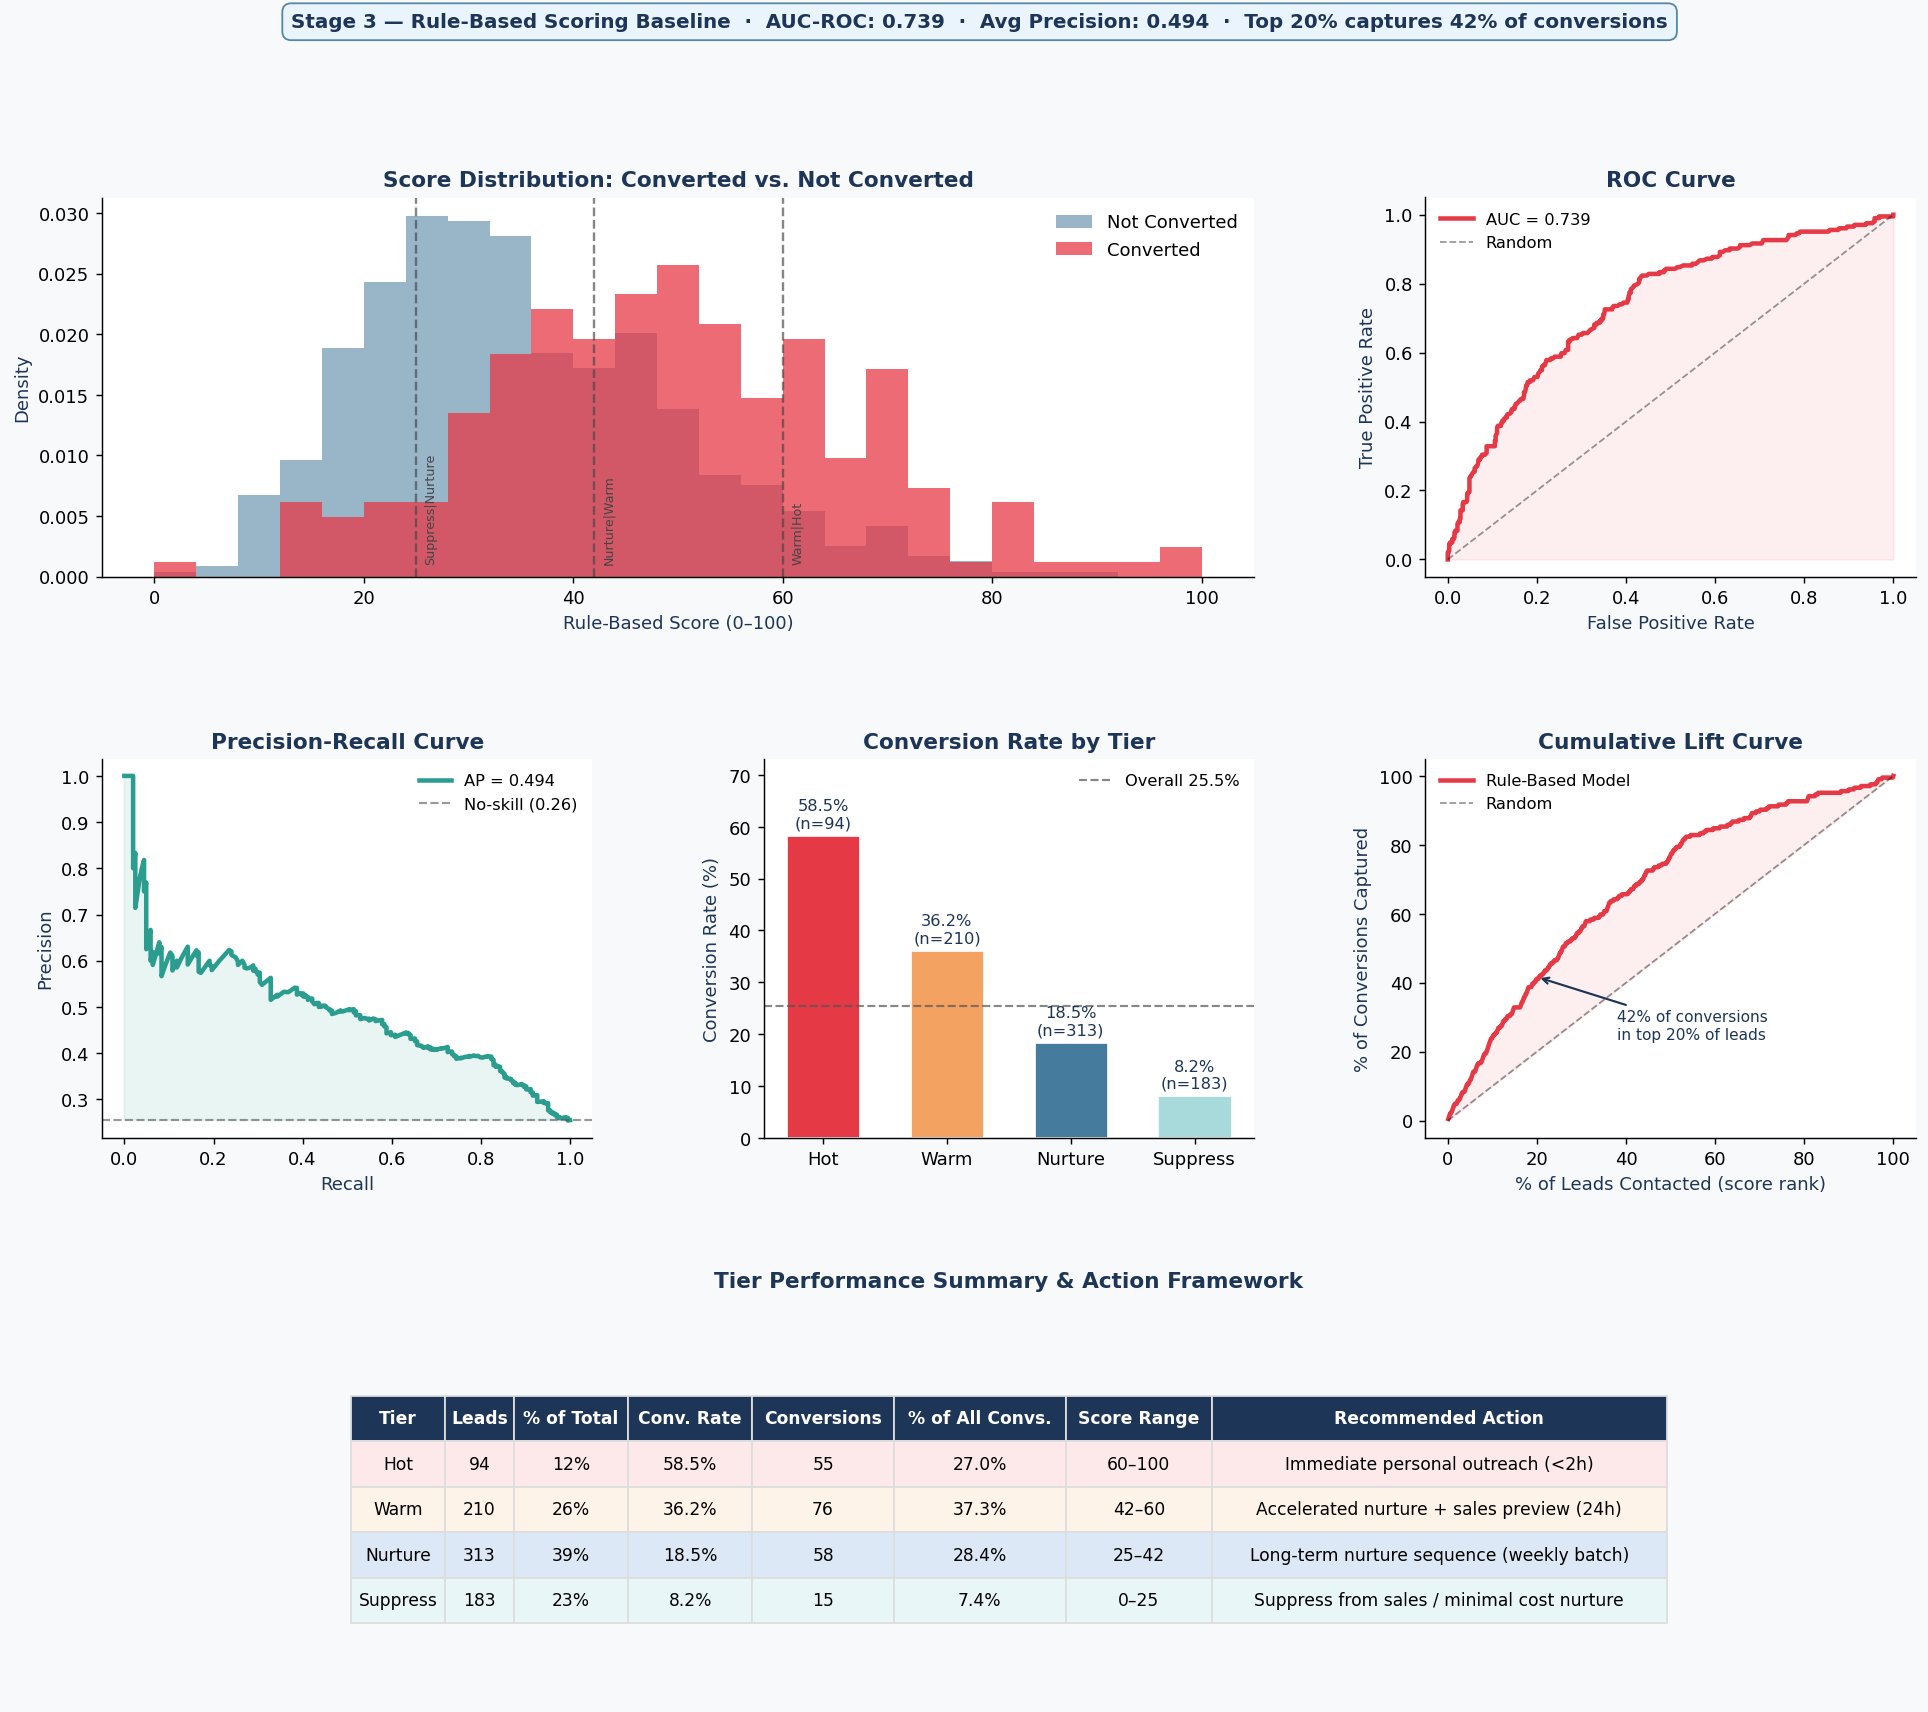

In [12]:
fig = plt.figure(figsize=(18, 15))
fig.patch.set_facecolor(COLORS["bg"])
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35)

# ── 5a. Score distribution ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor("white")
bins = np.linspace(0, 100, 26)
ax1.hist(df[df["converted"]==0]["score_0_100"], bins=bins, alpha=0.55,
         color="#457B9D", label="Not Converted", density=True)
ax1.hist(df[df["converted"]==1]["score_0_100"], bins=bins, alpha=0.75,
         color=COLORS["accent"], label="Converted", density=True)
for thresh, label in [(25,"Suppress|Nurture"), (42,"Nurture|Warm"), (60,"Warm|Hot")]:
    ax1.axvline(thresh, color="#444", lw=1.3, ls="--", alpha=0.65)
    ax1.text(thresh + 0.8, 0.001, label, fontsize=7, color="#444",
             rotation=90, va="bottom")
ax1.set_xlabel("Rule-Based Score (0–100)", color=COLORS["text"])
ax1.set_ylabel("Density", color=COLORS["text"])
ax1.set_title("Score Distribution: Converted vs. Not Converted",
              fontsize=12, color=COLORS["text"], fontweight="bold")
ax1.legend(frameon=False)

# ── 5b. ROC Curve ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor("white")
fpr, tpr, _ = roc_curve(y_true, y_score)
ax2.plot(fpr, tpr, color=COLORS["accent"], lw=2.5, label=f"AUC = {auc_roc:.3f}")
ax2.plot([0,1],[0,1], "k--", lw=1, alpha=0.4, label="Random")
ax2.fill_between(fpr, tpr, alpha=0.08, color=COLORS["accent"])
ax2.set_xlabel("False Positive Rate", color=COLORS["text"])
ax2.set_ylabel("True Positive Rate", color=COLORS["text"])
ax2.set_title("ROC Curve", fontsize=12, color=COLORS["text"], fontweight="bold")
ax2.legend(frameon=False, fontsize=9)

# ── 5c. Precision-Recall Curve ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor("white")
prec, rec, _ = precision_recall_curve(y_true, y_score)
ax3.plot(rec, prec, color="#2A9D8F", lw=2.5, label=f"AP = {avg_prec:.3f}")
ax3.axhline(baseline, color="#555", ls="--", lw=1.2, alpha=0.6,
            label=f"No-skill ({baseline:.2f})")
ax3.fill_between(rec, prec, baseline, where=(prec >= baseline),
                 alpha=0.1, color="#2A9D8F")
ax3.set_xlabel("Recall", color=COLORS["text"])
ax3.set_ylabel("Precision", color=COLORS["text"])
ax3.set_title("Precision-Recall Curve", fontsize=12, color=COLORS["text"], fontweight="bold")
ax3.legend(frameon=False, fontsize=9)

# ── 5d. Conversion rate by tier ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor("white")
tier_conv   = df.groupby("tier")["converted"].mean().reindex(TIER_ORDER)
tier_counts = df.groupby("tier").size().reindex(TIER_ORDER)
bars = ax4.bar(TIER_ORDER, tier_conv * 100,
               color=[COLORS[t] for t in TIER_ORDER],
               edgecolor="white", linewidth=1.5, width=0.6)
for bar, tier in zip(bars, TIER_ORDER):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f"{tier_conv[tier]:.1%}\n(n={tier_counts[tier]})",
             ha="center", va="bottom", fontsize=9, color=COLORS["text"])
ax4.axhline(baseline * 100, color="#555", ls="--", lw=1.2, alpha=0.7,
            label=f"Overall {baseline:.1%}")
ax4.set_ylabel("Conversion Rate (%)", color=COLORS["text"])
ax4.set_title("Conversion Rate by Tier", fontsize=12, color=COLORS["text"], fontweight="bold")
ax4.legend(frameon=False, fontsize=9)
ax4.set_ylim(0, max(tier_conv) * 125)

# ── 5e. Cumulative lift curve ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor("white")
df_s = df.sort_values("score_0_100", ascending=False).reset_index(drop=True)
df_s["cum_leads_pct"] = (df_s.index + 1) / len(df_s) * 100
df_s["cum_conv_pct"]  = df_s["converted"].cumsum() / y_true.sum() * 100
ax5.plot(df_s["cum_leads_pct"], df_s["cum_conv_pct"],
         color=COLORS["accent"], lw=2.5, label="Rule-Based Model")
ax5.plot([0,100],[0,100], "k--", lw=1, alpha=0.4, label="Random")
ax5.fill_between(df_s["cum_leads_pct"], df_s["cum_conv_pct"],
                 df_s["cum_leads_pct"], alpha=0.08, color=COLORS["accent"])
pct_at_20 = df_s[df_s["cum_leads_pct"] <= 20.5]["cum_conv_pct"].max()
ax5.annotate(f"{pct_at_20:.0f}% of conversions\nin top 20% of leads",
             xy=(20, pct_at_20), xytext=(38, pct_at_20 - 18),
             arrowprops=dict(arrowstyle="->", color=COLORS["text"], lw=1.2),
             fontsize=8.5, color=COLORS["text"])
ax5.set_xlabel("% of Leads Contacted (score rank)", color=COLORS["text"])
ax5.set_ylabel("% of Conversions Captured", color=COLORS["text"])
ax5.set_title("Cumulative Lift Curve", fontsize=12, color=COLORS["text"], fontweight="bold")
ax5.legend(frameon=False, fontsize=9)

# ── 5f. Tier summary table ───────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :])
ax6.set_facecolor("white")
ax6.axis("off")

actions = {
    "Hot":      "Immediate personal outreach (<2h)",
    "Warm":     "Accelerated nurture + sales preview (24h)",
    "Nurture":  "Long-term nurture sequence (weekly batch)",
    "Suppress": "Suppress from sales / minimal cost nurture",
}
tier_stats = []
for tier in TIER_ORDER:
    sub = df[df["tier"] == tier]
    cc  = sub["converted"].sum()
    tier_stats.append([
        tier, f"{len(sub):,}", f"{len(sub)/len(df):.0%}",
        f"{sub['converted'].mean():.1%}", f"{cc:,}",
        f"{cc/total_conv:.1%}",
        f"{sub['score_0_100'].min():.0f}–{sub['score_0_100'].max():.0f}",
        actions[tier],
    ])

col_labels = ["Tier","Leads","% of Total","Conv. Rate",
              "Conversions","% of All Convs.","Score Range","Recommended Action"]
table = ax6.table(cellText=tier_stats, colLabels=col_labels,
                  loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.1)
table.auto_set_column_width(list(range(len(col_labels))))

tier_bg = {"Hot":"#fde8ea","Warm":"#fef3e8","Nurture":"#dce8f5","Suppress":"#e8f6f7"}
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#ddd")
    if row == 0:
        cell.set_facecolor(COLORS["text"])
        cell.set_text_props(color="white", fontweight="bold")
    elif row > 0:
        cell.set_facecolor(tier_bg.get(tier_stats[row-1][0], "white"))

ax6.set_title("Tier Performance Summary & Action Framework",
              fontsize=12, color=COLORS["text"], fontweight="bold", pad=18)

fig.text(0.5, 0.975,
         f"Stage 3 — Rule-Based Scoring Baseline  ·  AUC-ROC: {auc_roc:.3f}  ·  "
         f"Avg Precision: {avg_prec:.3f}  ·  "
         f"Top 20% captures {pct_at_20:.0f}% of conversions",
         ha="center", va="top", fontsize=11, color=COLORS["text"], fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.45", facecolor="#E8F4FD",
                   edgecolor="#457B9D", alpha=0.9))

# Save figure using config path
fig_path = cfg.OUT_FIGURES / "stage3_baseline_report.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor=COLORS["bg"])
print(f"Figure saved → {fig_path}")
plt.show()


## 6. Save Scored Leads

In [13]:
# ── Save scored leads to config.OUT_SCORES ───────────────────────────────────
scores_path = cfg.OUT_SCORES / "stage3_scored_leads.csv"
scores_path.parent.mkdir(parents=True, exist_ok=True)

df[["lead_id", "score_0_100", "percentile", "tier"]].to_csv(scores_path, index=False)
print(f"Scored leads saved → {scores_path}")
print(f"Shape: {df[['lead_id','score_0_100','percentile','tier']].shape}")
df[["lead_id","score_0_100","percentile","tier"]].head(10)


Scored leads saved → /home/cairo/code/portfolio/lead-scoring/outputs/scores/stage3_scored_leads.csv
Shape: (800, 4)


,lead_id,score_0_100,percentile,tier
0,L00001,29.6,33.9,Nurture
1,L00002,42.9,63.0,Warm
2,L00003,39.1,56.2,Nurture
3,L00004,35.6,48.8,Nurture
4,L00005,24.3,20.9,Suppress
5,L00006,51.3,78.3,Warm
6,L00007,62.5,91.0,Hot
7,L00008,45.7,69.1,Warm
8,L00009,38.5,55.2,Nurture
9,L00010,37.0,51.9,Nurture


## 7. Stage 3 Summary & Handoff to Stage 4

### What we built
A rule-based scoring engine that assigns every lead a 0–100 score and an action tier based on five signal families: high-intent behavioural, email engagement, product trial depth, firmographic fit, and interaction terms.

### Key results

| Metric | Value |
|---|---|
| **AUC-ROC** | **0.739** |
| **Average Precision** | **0.494** (vs. 0.255 baseline — 1.9× lift) |
| **Top 20% lead capture** | **~42% of all conversions** |

### Tier performance

| Tier | Leads | Conv. Rate | Captures |
|---|---|---|---|
| Hot (≥60) | 94 (12%) | 58.5% | 27% of all conversions |
| Warm (42–59) | 210 (26%) | 36.2% | 37% |
| Nurture (25–41) | 313 (39%) | 18.5% | 28% |
| Suppress (<25) | 183 (23%) | 8.2% | 7% |

### Business interpretation
Hot + Warm together represent **38% of the pipeline but capture 64% of conversions**. A sales team following this system spends less than half its effort and still reaches nearly two-thirds of deals.

### Config note
`config.SCORE_TIERS` currently uses `80/60/40` thresholds (initial design). After calibrating against the actual score distribution, the operative thresholds are `60/42/25`. Update `config.SCORE_TIERS` before Stage 5 to reflect this.
